# Task 2: Exploratory Data Analysis – Retail Store Sales

## Data Analyst Internship – SWYNEX

This project performs exploratory data analysis on the cleaned Retail Store Sales dataset from Task 1.

### Objectives
- Calculate important business statistics
- Analyze sales by category, payment method, and location
- Identify monthly sales trends
- Identify top-performing products
- Detect potential outliers
- Generate useful business insights

### Load the cleaned dataset


In [27]:
import pandas as pd

df = pd.read_csv("/cleaned_retail_store_sales.csv")

df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9,247.5,Credit Card,Online,2022-05-07,Unknown
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7,87.5,Digital Wallet,Online,2022-10-02,False


In [28]:
df.shape

(12575, 11)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              12575 non-null  object 
 4   Price Per Unit    12575 non-null  float64
 5   Quantity          12575 non-null  int64  
 6   Total Spent       12575 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  12575 non-null  object 
dtypes: float64(2), int64(1), object(8)
memory usage: 1.1+ MB


### Basic Statistical Analysis

In [30]:
df.describe()

,Price Per Unit,Quantity,Total Spent
count,12575.000000,12575.000000,12575.000000
mean,23.369304,5.552922,130.075109
std,10.748728,2.790274,93.538217
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,52.000000
50%,23.000000,6.000000,110.000000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


### Calculate Key Business Metrics

In [31]:
print("Total Transactions:", df["Transaction ID"].nunique())
print("Total Sales:", df["Total Spent"].sum())
print("Average Transaction Value:", df["Total Spent"].mean())
print("Median Transaction Value:", df["Total Spent"].median())
print("Total Quantity Sold:", df["Quantity"].sum())
print("Average Quantity per Transaction:", df["Quantity"].mean())

Total Transactions: 12575
Total Sales: 1635694.5
Average Transaction Value: 130.0751093439364
Median Transaction Value: 110.0
Total Quantity Sold: 69828
Average Quantity per Transaction: 5.552922465208748


### Category-wise Sales

In [32]:
category_sales = df.groupby("Category")["Total Spent"].sum().sort_values(ascending=False)

category_sales

,Total Spent
Category,
Butchers,216480.5
Electric household essentials,215297.5
Beverages,206854.5
Furniture,205390.0
Food,205225.0
Computers and electric accessories,202023.5
Patisserie,194531.5
Milk Products,189892.0


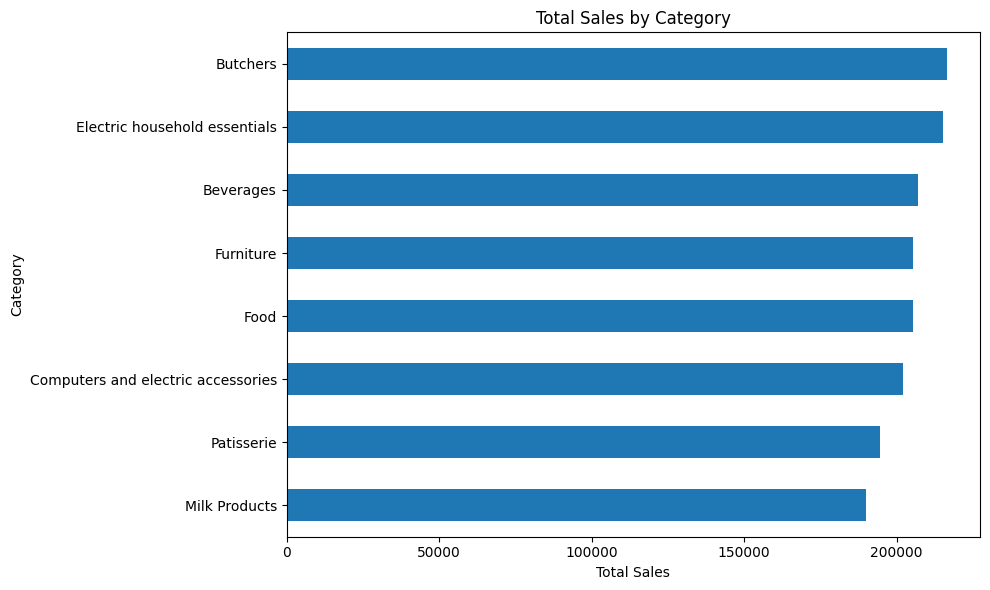

In [33]:
import matplotlib.pyplot as plt

category_sales.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Total Sales by Category")
plt.xlabel("Total Sales")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### Sales by Payment Method

In [34]:
payment_sales = (
    df.groupby("Payment Method")["Total Spent"]
    .sum()
    .sort_values(ascending=False)
)

payment_sales

,Total Spent
Payment Method,
Cash,566773.5
Digital Wallet,535088.5
Credit Card,533832.5


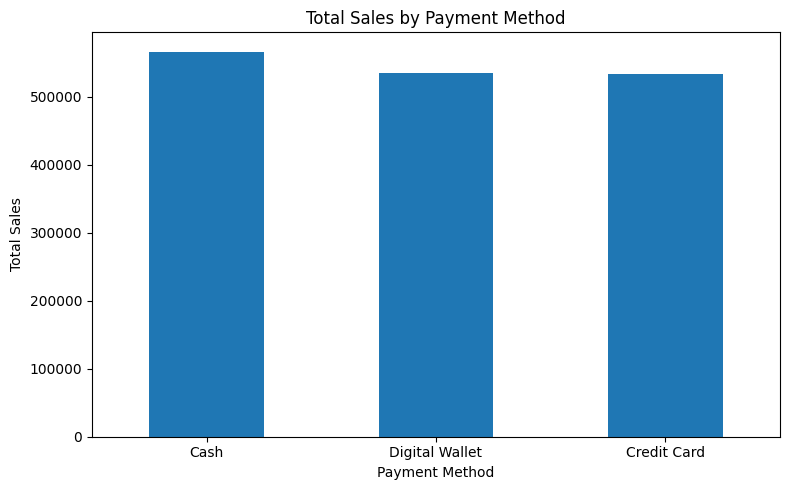

In [35]:
payment_sales.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Total Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Sales by Location

In [36]:
location_sales = (
    df.groupby("Location")["Total Spent"]
    .sum()
    .sort_values(ascending=False)
)

location_sales

,Total Spent
Location,
Online,831132.5
In-store,804562.0


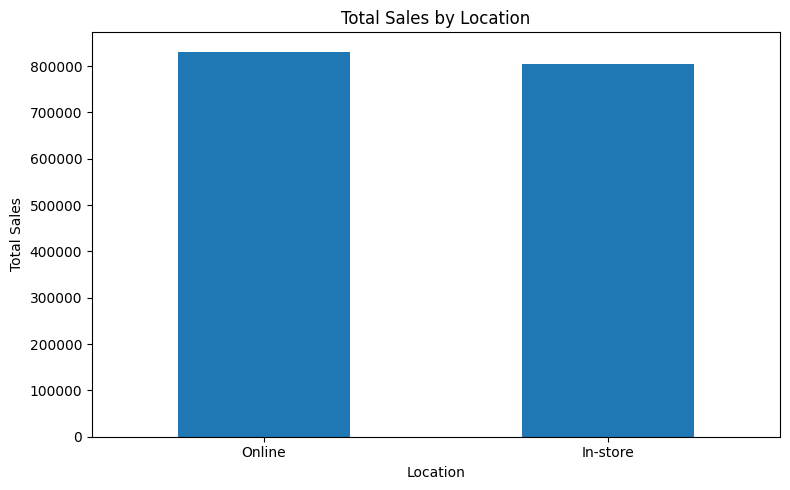

In [37]:
location_sales.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Total Sales by Location")
plt.xlabel("Location")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Convert the date column

In [38]:
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])

In [39]:
df["Transaction Date"].dtype

dtype('<M8[ns]')

### Monthly Sales Trend

In [40]:
df["Month"] = df["Transaction Date"].dt.to_period("M")

In [41]:
monthly_sales = (
    df.groupby("Month")["Total Spent"]
    .sum()
)

monthly_sales

,Total Spent
Month,
2022-01,56198.5
2022-02,46239.0
2022-03,43193.0
2022-04,42577.5
2022-05,42066.5
2022-06,44361.0
2022-07,47447.0
2022-08,43415.5
2022-09,47541.5


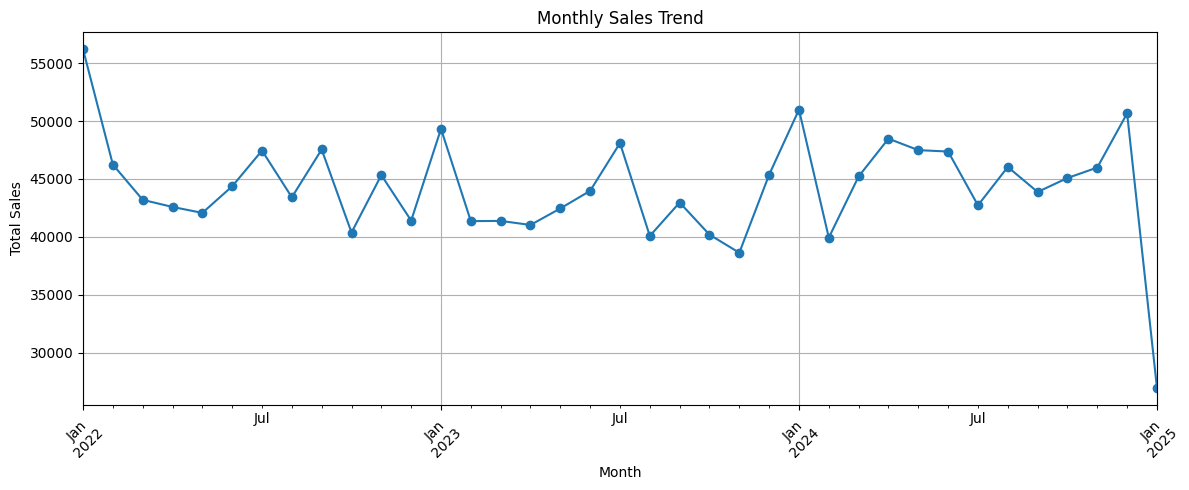

In [42]:
monthly_sales.plot(
    kind="line",
    figsize=(12, 5),
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Find the Top-Selling Products

In [43]:
item_sales = (
    df.groupby("Item")["Total Spent"]
    .sum()
    .sort_values(ascending=False)
)

item_sales.head(10)

,Total Spent
Item,
Item_25_FUR,27101.0
Item_25_EHE,26732.0
Item_24_FUR,23739.5
Item_25_BUT,23452.0
Item_25_FOOD,22755.0
Item_22_BUT,22374.5
Item_23_BUT,21926.0
Item_19_MILK,21600.0
Item_23_EHE,21546.0


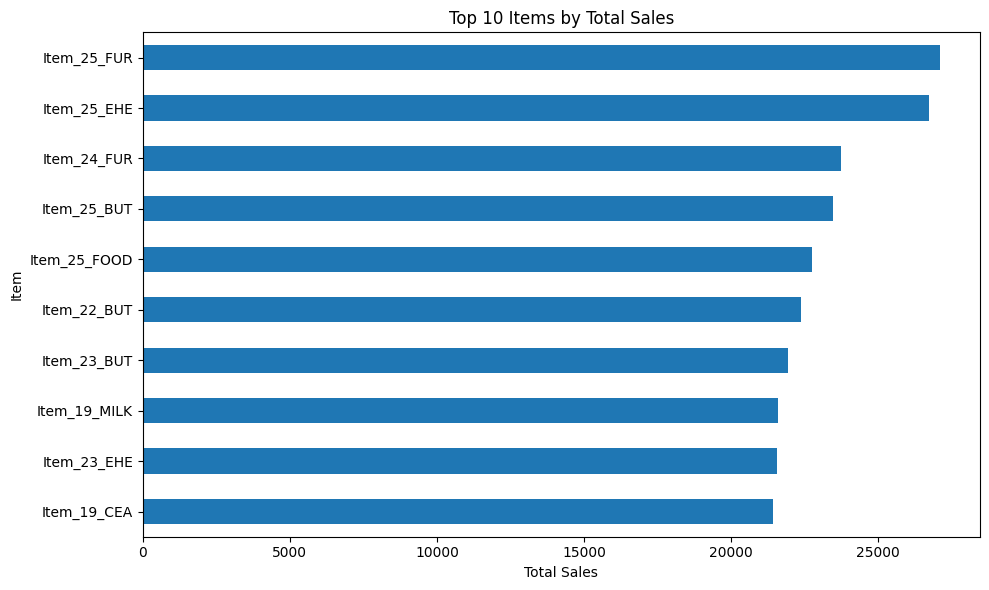

In [44]:
top_items = item_sales.head(10).sort_values()

top_items.plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Items by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Item")
plt.tight_layout()
plt.show()

### Discount Analysis

In [45]:
discount_sales = (
    df.groupby("Discount Applied")["Total Spent"]
    .sum()
    .sort_values(ascending=False)
)

discount_sales

,Total Spent
Discount Applied,
True,552085.5
False,543075.5
Unknown,540533.5


### Find anomalies

In [46]:
Q1 = df["Total Spent"].quantile(0.25)
Q3 = df["Total Spent"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 52.0
Q3: 192.0
IQR: 140.0
Lower Bound: -158.0
Upper Bound: 402.0


### Count and inspect the outliers

In [47]:
outliers = df[df["Total Spent"] > upper_bound]

print("Number of outliers:", len(outliers))
print("Percentage of outliers:", len(outliers) / len(df) * 100)

outliers[[
    "Transaction ID",
    "Category",
    "Item",
    "Price Per Unit",
    "Quantity",
    "Total Spent"
]].sort_values("Total Spent", ascending=False).head(10)

Number of outliers: 60
Percentage of outliers: 0.4771371769383698


,Transaction ID,Category,Item,Price Per Unit,Quantity,Total Spent
27,TXN_1599706,Furniture,Item_25_FUR,41.0,10,410.0
133,TXN_2953434,Furniture,Item_25_FUR,41.0,10,410.0
339,TXN_4374445,Food,Item_25_FOOD,41.0,10,410.0
869,TXN_1814138,Beverages,Item_25_BEV,41.0,10,410.0
1060,TXN_3710081,Furniture,Item_25_FUR,41.0,10,410.0
1088,TXN_1273334,Beverages,Item_25_BEV,41.0,10,410.0
1468,TXN_1938135,Butchers,Item_25_BUT,41.0,10,410.0
1505,TXN_8520397,Electric household essentials,Item_25_EHE,41.0,10,410.0
1568,TXN_8048041,Butchers,Item_25_BUT,41.0,10,410.0
1950,TXN_1860120,Furniture,Item_25_FUR,41.0,10,410.0


### Final analysis: transaction count by category

In [48]:
category_transactions = (
    df.groupby("Category")["Transaction ID"]
    .nunique()
    .sort_values(ascending=False)
)

category_transactions

,Transaction ID
Category,
Electric household essentials,1591
Furniture,1591
Food,1588
Milk Products,1584
Butchers,1568
Beverages,1567
Computers and electric accessories,1558
Patisserie,1528


### Calculate sales per transaction by category

In [49]:
category_performance = (
    df.groupby("Category")
    .agg(
        Total_Sales=("Total Spent", "sum"),
        Transactions=("Transaction ID", "nunique")
    )
)

category_performance["Sales_Per_Transaction"] = (
    category_performance["Total_Sales"] /
    category_performance["Transactions"]
)

category_performance.sort_values(
    "Sales_Per_Transaction",
    ascending=False
)

,Total_Sales,Transactions,Sales_Per_Transaction
Category,,,
Butchers,216480.5,1568,138.061543
Electric household essentials,215297.5,1591,135.322124
Beverages,206854.5,1567,132.006701
Computers and electric accessories,202023.5,1558,129.668485
Food,205225.0,1588,129.234887
Furniture,205390.0,1591,129.094909
Patisserie,194531.5,1528,127.311191
Milk Products,189892.0,1584,119.881313


## Save the analysis results

In [50]:
payment_performance = (
    df.groupby("Payment Method")
    .agg(
        Total_Sales=("Total Spent", "sum"),
        Transactions=("Transaction ID", "nunique"),
        Average_Transaction=("Total Spent", "mean")
    )
    .sort_values("Average_Transaction", ascending=False)
)

payment_performance

,Total_Sales,Transactions,Average_Transaction
Payment Method,,,
Cash,566773.5,4310,131.501972
Credit Card,533832.5,4121,129.539554
Digital Wallet,535088.5,4144,129.123673


# Key Insights

1. The dataset contains 12,575 transactions with total sales of 1,635,694.50.

2. The average transaction value is 130.08, while the median transaction value is 110.00. This indicates that some higher-value transactions increase the average.

3. Butchers generated the highest category sales at 216,480.50, while Milk Products generated the lowest at 189,892.00.

4. Online sales were 831,132.50, which was higher than in-store sales of 804,562.00.

5. Item_25_FUR was the highest-selling individual item by total sales, generating 27,101.00.

6. The IQR analysis identified 60 high-value transactions above the upper bound of 402. These represent approximately 0.48% of all transactions. The identified transactions appear to be valid high-value transactions because their Total Spent values are consistent with Price Per Unit multiplied by Quantity.

7. Butchers had the highest sales per transaction at 138.06, while Milk Products had the lowest at 119.88.

8. Cash had the highest average transaction value among payment methods at 131.50, while Digital Wallet had the lowest at 129.12. The differences were relatively small.


# Conclusion

The exploratory analysis provided an overview of sales performance across categories, payment methods, locations, products, and time periods. The analysis also identified high-value transactions using the IQR method and examined transaction-level patterns.

Overall, the dataset shows relatively balanced transaction volumes across categories, with differences in sales performance influenced by transaction values. The results provide a useful foundation for further business analysis and visualization.